<a href="https://colab.research.google.com/github/jashvidesai2030/IEMS447FinalProject/blob/main/IEMS447FinalHeartDiseaseSex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
=============================================================================
CDC BRFSS 2021 — Heart Disease Risk Prediction Fairness Study
=============================================================================
Research Question:
    How do fairness interventions affect treatment allocation and missed
    patients in heart disease risk prediction?

Dataset:
    2021 CDC Behavioral Risk Factor Surveillance System (BRFSS)
    Official public-use data — 438,693 respondents, 304 variables
    Source: https://www.cdc.gov/brfss/annual_data/annual_2021.html

Fairness Definition:
    Equalised False Negative Rate (FNR) across sex groups.
    A high FNR means heart disease patients in that group are
    disproportionately missed — a serious clinical equity concern.
=============================================================================
"""

# ── Installs (run this cell first in Colab) ───────────────────────────────
!pip install pyreadstat pandas numpy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 38.2 MB/s eta 0:00:00


STEP 1 — Loading 2021 CDC BRFSS Dataset
  URL: https://www.cdc.gov/brfss/annual_data/2021/files/LLCP2021XPT.zip
  This may take 1–3 minutes depending on your connection.

  Extracting XPT from ZIP …
  Saved: LLCP2021.XPT
Found: ['LLCP2021.XPT ']
Renamed 'LLCP2021.XPT ' → 'LLCP2021.XPT'

  Reading XPT file with pyreadstat (may take ~30 seconds) …

  Raw dataset shape : (438693, 303)
  Total variables   : 303
  Total respondents : 438,693

STEP 2 — Defining Heart Disease Outcome (_MICHD)

  Raw '_MICHD' value counts:
_MICHD
1.0     35323
2.0    398735
NaN      4635

  After dropping missing/refused: 434,058 respondents
  Heart disease prevalence: 8.1%
  Cases: 35,323
  Non-cases: 398,735

STEP 3 — Defining Fairness Group (Sex)
  Using sex variable: _SEX

  Raw '_SEX' value counts:
_SEX
1.0    201460
2.0    232598

  Sex group mapping (BRFSS 2021 coding):
    1 → Male    (201,460 respondents, 46.4%)
    2 → Female  (232,598 respondents, 53.6%)

STEP 4 — Selecting Predictor Variables

  Va

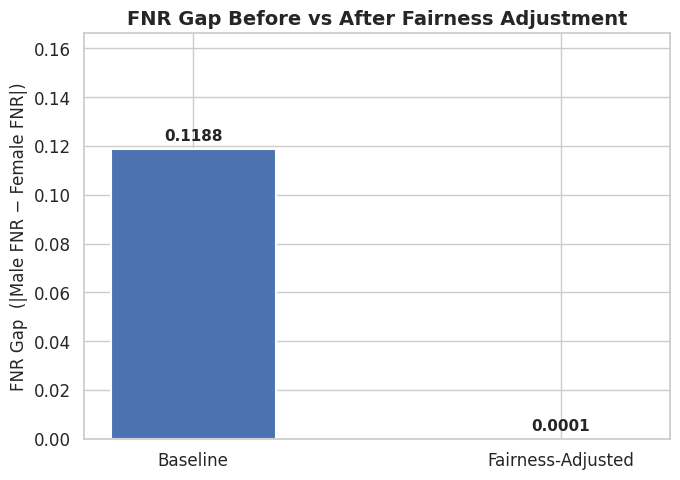

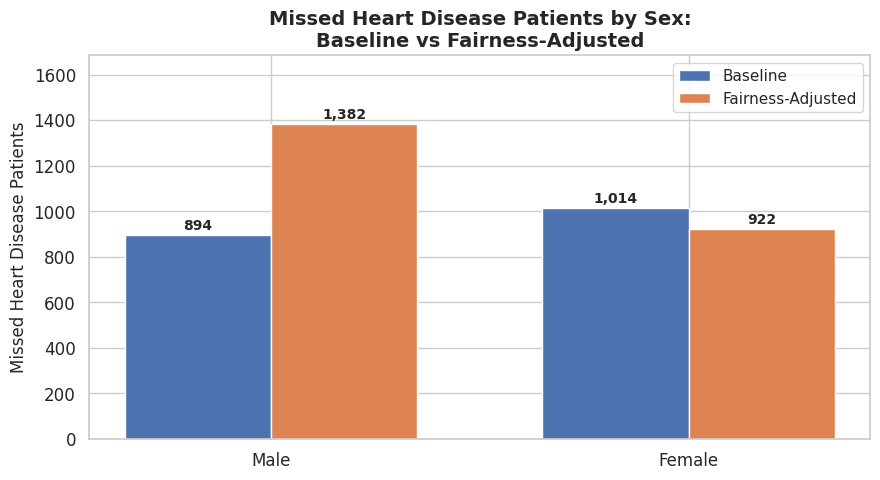

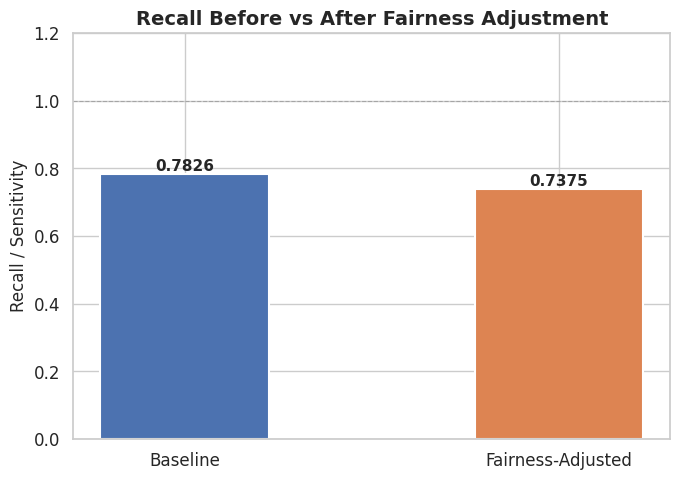

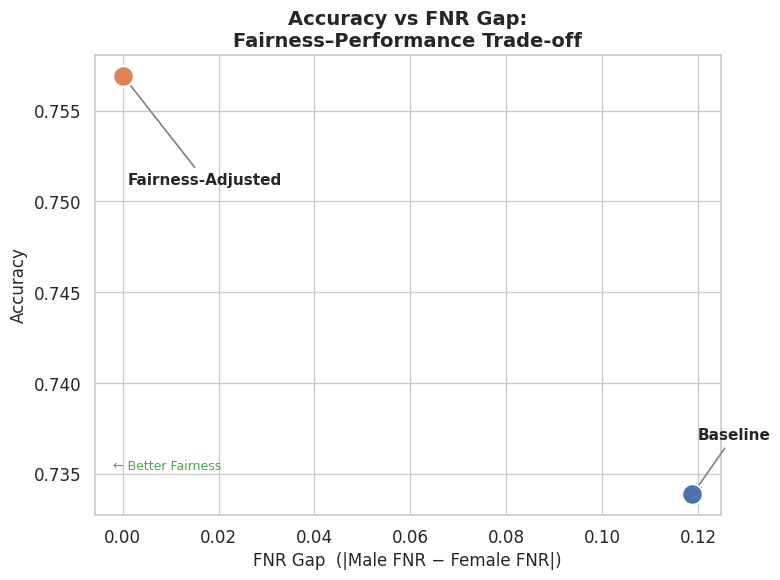

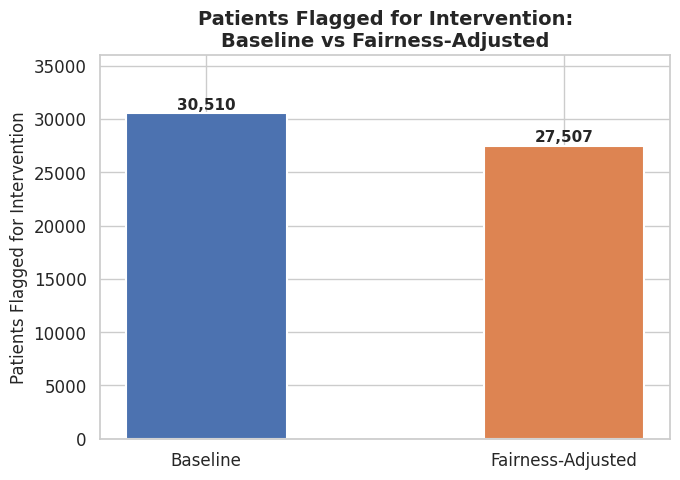


STEP 12 — Interpretive Summary

╔══════════════════════════════════════════════════════════════════════╗
║              INTERPRETATION OF RESULTS                              ║
╠══════════════════════════════════════════════════════════════════════╣

  1. FNR GAP (Fairness Criterion)
     ✓ REDUCED
     Baseline FNR gap   : 0.1188
     Adjusted FNR gap   : 0.0001
     → Sex-based disparity in missed heart disease patients was successfully reduced.

  2. ACCURACY
     Change: +0.0230 (+2.30%)
     → Accuracy improved after fairness adjustment.
       The objective penalises accuracy loss to limit this trade-off.

  3. RECALL / SENSITIVITY
     Baseline  : 0.7826
     Adjusted  : 0.7375
     → Recall decreased.
       More heart disease patients
       missed overall (+396 patients).

  4. CLINICAL & FAIRNESS IMPLICATIONS
     • Disparate FNRs mean one sex group's heart disease is
       systematically under-detected — a direct equity harm.
     • Sex-specific thresholds address structu

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import io
import os
import zipfile
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix)

import glob, os

# =============================================================================
# 1. DOWNLOAD AND LOAD THE 2021 BRFSS XPT FILE
# =============================================================================
print("=" * 70)
print("STEP 1 — Loading 2021 CDC BRFSS Dataset")
print("=" * 70)

# Official CDC download URL for the 2021 BRFSS SAS Transport (XPT) zip
BRFSS_ZIP_URL = (
    "https://www.cdc.gov/brfss/annual_data/2021/files/LLCP2021XPT.zip"
)
LOCAL_ZIP  = "LLCP2021XPT.zip"
LOCAL_XPT  = "LLCP2021.XPT"

# ── Download if not already cached ───────────────────────────────────────
def download_brfss(url=BRFSS_ZIP_URL, zip_path=LOCAL_ZIP, xpt_path=LOCAL_XPT):
    """
    Download the 2021 BRFSS ZIP from CDC and extract the XPT file.
    Skips download if the XPT is already present locally.

    Manual alternative (if CDC blocks automated downloads):
      1. Visit https://www.cdc.gov/brfss/annual_data/annual_2021.html
      2. Download '2021 BRFSS Data (SAS Transport Format)' (~64 MB ZIP)
      3. Unzip to get LLCP2021.XPT
      4. Upload LLCP2021.XPT to your Colab session, then re-run.
    """
    if os.path.exists(xpt_path):
        print(f"  XPT file already present: {xpt_path}")
        return xpt_path

    print(f"  Downloading from CDC (~64 MB) …")
    print(f"  URL: {url}")
    print("  This may take 1–3 minutes depending on your connection.\n")

    try:
        urllib.request.urlretrieve(url, zip_path)
    except urllib.error.URLError as e:
        raise RuntimeError(
            f"\nDownload failed: {e}\n\n"
            "Please download the file manually:\n"
            "  1. Go to https://www.cdc.gov/brfss/annual_data/annual_2021.html\n"
            "  2. Click '2021 BRFSS Data (SAS Transport Format)'\n"
            "  3. Unzip to get LLCP2021.XPT\n"
            "  4. In Colab: Files panel → Upload → select LLCP2021.XPT\n"
            "  5. Re-run this cell.\n"
        )

    print("  Extracting XPT from ZIP …")
    with zipfile.ZipFile(zip_path, "r") as z:
        xpt_name = [n for n in z.namelist() if n.strip().upper().endswith(".XPT")][0]
        z.extract(xpt_name, path=".")
        extracted = xpt_name.strip()   # ← strip trailing space

    # Rename to a predictable filename if needed
    if extracted != xpt_path:
        os.rename(extracted, xpt_path)

    print(f"  Saved: {xpt_path}")
    return xpt_path


xpt_path = download_brfss()
# Find the file with the trailing space and rename it cleanly
spaced = glob.glob("LLCP2021.XPT*")  # catches 'LLCP2021.XPT '
print("Found:", spaced)
for f in spaced:
    clean = f.strip()
    if f != clean:
        os.rename(f, clean)
        print(f"Renamed '{f}' → '{clean}'")

xpt_path = "LLCP2021.XPT"

# ── Read XPT into pandas ──────────────────────────────────────────────────
print("\n  Reading XPT file with pyreadstat (may take ~30 seconds) …")
import pyreadstat

df_raw, meta = pyreadstat.read_xport(xpt_path)

# Standardise column names to UPPER CASE (XPT sometimes uses mixed case)
df_raw.columns = [c.upper() for c in df_raw.columns]

print(f"\n  Raw dataset shape : {df_raw.shape}")
print(f"  Total variables   : {df_raw.shape[1]}")
print(f"  Total respondents : {df_raw.shape[0]:,}")

# =============================================================================
# 2. DEFINE THE HEART DISEASE OUTCOME  (_MICHD)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 2 — Defining Heart Disease Outcome (_MICHD)")
print("=" * 70)

# _MICHD: Respondents that have ever reported having coronary heart disease
# (CHD) or myocardial infarction (MI).
#   1 = Reported having MI or CHD
#   2 = Did not report having MI or CHD
#   Missing / 9 = don't know / refused

OUTCOME_COL = "_MICHD"

if OUTCOME_COL not in df_raw.columns:
    raise ValueError(
        f"Column '{OUTCOME_COL}' not found in dataset. "
        f"Available calculated columns: "
        f"{[c for c in df_raw.columns if c.startswith('_M')][:20]}"
    )

print(f"\n  Raw '{OUTCOME_COL}' value counts:")
print(df_raw[OUTCOME_COL].value_counts(dropna=False).sort_index().to_string())

# Keep only valid responses (1 = heart disease, 2 = no heart disease)
df = df_raw[df_raw[OUTCOME_COL].isin([1.0, 2.0])].copy()

# Recode to binary: 1 = heart disease, 0 = no heart disease
df["heart_disease_binary"] = (df[OUTCOME_COL] == 1.0).astype(int)

print(f"\n  After dropping missing/refused: {len(df):,} respondents")
print(f"  Heart disease prevalence: {df['heart_disease_binary'].mean():.1%}")
print(f"  Cases: {df['heart_disease_binary'].sum():,}")
print(f"  Non-cases: {(df['heart_disease_binary'] == 0).sum():,}")

# =============================================================================
# 3. DEFINE FAIRNESS GROUP  (_SEX)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 3 — Defining Fairness Group (Sex)")
print("=" * 70)

# BRFSS uses '_SEX' or 'SEX' depending on year.
# 2021 codebook: _SEX  1=Male, 2=Female  (no missing / refused codes)
SEX_COL = "_SEX" if "_SEX" in df.columns else "SEX"

print(f"  Using sex variable: {SEX_COL}")
print(f"\n  Raw '{SEX_COL}' value counts:")
print(df[SEX_COL].value_counts(dropna=False).sort_index().to_string())

# Keep only valid sex codes (1 and 2)
df = df[df[SEX_COL].isin([1.0, 2.0])].copy()

# Create a clean integer sex column: 1=Male, 2=Female
df["sex_group"] = df[SEX_COL].astype(int)

SEX_MAP  = {1: "Male", 2: "Female"}
SEX_CODE = {1: 1, 2: 2}   # kept as 1/2 to match BRFSS coding

print(f"\n  Sex group mapping (BRFSS 2021 coding):")
for code, label in SEX_MAP.items():
    n = (df["sex_group"] == code).sum()
    print(f"    {code} → {label:6s}  ({n:,} respondents, "
          f"{100*n/len(df):.1f}%)")

# =============================================================================
# 4. SELECT PREDICTOR VARIABLES
# =============================================================================
print("\n" + "=" * 70)
print("STEP 4 — Selecting Predictor Variables")
print("=" * 70)

# Candidate variables and their BRFSS 2021 coding notes:
#
#  _AGEG5YR  : Age in 5-year groups  (1–13; 14=don't know/refused)
#  _BMI5CAT  : BMI category  (1=underweight,2=normal,3=overweight,4=obese; 9=missing)
#  GENHLTH   : General health (1=Excellent..5=Poor; 7=dk, 9=refused)
#  _SMOKER3  : Computed smoking status (1=every day..4=never; 9=missing)
#  DIABETE4  : Diabetes (1=yes,2=yes-only preg,3=no,4=borderline; 7=dk,9=refused)
#  _TOTINDA  : Physical activity (1=yes,2=no; 9=missing)
#  BPHIGH6   : High blood pressure (1=yes,2=yes-only preg,3=no,4=borderline; 7=dk,9=ref)
#  TOLDHI3   : High cholesterol (1=yes,2=no; 7=dk,9=refused)
#  _RACE     : Race/ethnicity (1–8; 9=multiracial/other)
#  _SEX / SEX: Sex (1=Male, 2=Female)

CANDIDATE_VARS = {
    "_AGEG5YR" : {"valid": set(range(1, 14)), "type": "categorical"},
    "_BMI5CAT" : {"valid": {1, 2, 3, 4},      "type": "categorical"},
    "GENHLTH"  : {"valid": {1, 2, 3, 4, 5},   "type": "categorical"},
    "_SMOKER3" : {"valid": {1, 2, 3, 4},       "type": "categorical"},
    "DIABETE4" : {"valid": {1, 2, 3, 4},       "type": "categorical"},
    "_TOTINDA" : {"valid": {1, 2},             "type": "categorical"},
    "BPHIGH6"  : {"valid": {1, 2, 3, 4},       "type": "categorical"},
    "TOLDHI3"  : {"valid": {1, 2},             "type": "categorical"},
    "_RACE"    : {"valid": set(range(1, 10)),   "type": "categorical"},
    SEX_COL    : {"valid": {1, 2},             "type": "categorical"},
}

# Keep only variables that exist in the loaded dataset
selected_vars   = {}
missing_from_df = []

for var, info in CANDIDATE_VARS.items():
    if var in df.columns:
        selected_vars[var] = info
    else:
        missing_from_df.append(var)

print(f"\n  Variables selected ({len(selected_vars)}):")
for var, info in selected_vars.items():
    print(f"    {var:12s}  type={info['type']}  "
          f"valid codes={sorted(info['valid'])}")

if missing_from_df:
    print(f"\n  Variables NOT found in dataset (skipped): {missing_from_df}")

# =============================================================================
# 5. PREPARE MODELLING DATASET
# =============================================================================
print("\n" + "=" * 70)
print("STEP 5 — Preparing Modelling Dataset")
print("=" * 70)

df_model = df.copy()

# Filter each variable to valid codes only (drop rows with refused/dk/missing)
for var, info in selected_vars.items():
    valid = info["valid"]
    before = len(df_model)
    df_model = df_model[df_model[var].isin([float(v) for v in valid])]
    dropped  = before - len(df_model)
    if dropped > 0:
        print(f"  Dropped {dropped:,} rows with invalid '{var}' codes")

# Convert selected variables to integer for cleaner display / encoding
feature_cols = list(selected_vars.keys())
for col in feature_cols:
    df_model[col] = df_model[col].astype(int)

# Final arrays
X      = df_model[feature_cols].copy()
y      = df_model["heart_disease_binary"].values
groups = df_model["sex_group"].values   # 1=Male, 2=Female

print(f"\n  Final sample size        : {len(X):,}")
print(f"  Heart disease prevalence : {y.mean():.1%}  ({y.sum():,} cases)")
print(f"\n  Sex group counts:")
for code, label in SEX_MAP.items():
    n = (groups == code).sum()
    hd = y[groups == code].sum()
    print(f"    {label:6s} (code={code}): {n:,} respondents, "
          f"{hd:,} heart disease cases ({100*hd/n:.1f}%)")

print(f"\n  Heart disease by sex:")
for code, label in SEX_MAP.items():
    mask = groups == code
    prev = y[mask].mean()
    print(f"    {label:6s}: {prev:.1%} prevalence")

# Identify categorical vs numeric columns for the pipeline
# All selected BRFSS vars are categorical codes → use OneHotEncoder
cat_cols = [c for c in feature_cols if selected_vars[c]["type"] == "categorical"]
num_cols = [c for c in feature_cols if selected_vars[c]["type"] == "numeric"]

print(f"\n  Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"  Numeric features    ({len(num_cols)}): {num_cols}")

# =============================================================================
# 6. TRAIN / TEST SPLIT
# =============================================================================
print("\n" + "=" * 70)
print("STEP 6 — 70/30 Stratified Train-Test Split (random_state=42)")
print("=" * 70)

X_train, X_test, y_train, y_test, grp_train, grp_test = train_test_split(
    X, y, groups,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\n  Train : {len(X_train):,}  ({100*len(X_train)/len(X):.1f}%)")
print(f"  Test  : {len(X_test):,}  ({100*len(X_test)/len(X):.1f}%)")
print(f"  Test heart disease prevalence: {y_test.mean():.1%}")

# =============================================================================
# 7. TRAIN LOGISTIC REGRESSION WITH PREPROCESSING PIPELINE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 7 — Training Logistic Regression Pipeline")
print("=" * 70)

# Build ColumnTransformer:
#   - OneHotEncoder for all categorical BRFSS codes
#   - StandardScaler for any numeric columns (none here, but included for generality)
transformers = []
if cat_cols:
    transformers.append(
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    )
if num_cols:
    transformers.append(
        ("num", StandardScaler(), num_cols)
    )

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # corrects for class imbalance
        random_state=42,
        solver="lbfgs",
    ))
])

print("\n  Fitting pipeline …")
pipeline.fit(X_train, y_train)

# Predicted probability of heart disease (positive class = 1)
risk_scores = pipeline.predict_proba(X_test)[:, 1]

print("  Model trained successfully.")
print(f"  Risk score range on test set: [{risk_scores.min():.4f}, "
      f"{risk_scores.max():.4f}]")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_threshold(scores, threshold):
    """Single global threshold → binary predictions."""
    return (scores >= threshold).astype(int)


def apply_group_thresholds(scores, grps, male_thresh, female_thresh):
    """Sex-specific thresholds → binary predictions. 1=Male, 2=Female."""
    preds = np.zeros(len(scores), dtype=int)
    preds[grps == 1] = (scores[grps == 1] >= male_thresh).astype(int)
    preds[grps == 2] = (scores[grps == 2] >= female_thresh).astype(int)
    return preds


def compute_metrics(y_true, y_pred, grps):
    """
    Return a dict of performance and fairness metrics.
    Groups: 1=Male, 2=Female.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fnr_overall    = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    def group_stats(mask):
        yt, yp = y_true[mask], y_pred[mask]
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tn_g, fp_g, fn_g, tp_g = cm.ravel()
        fnr_g   = fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else 0.0
        missed_g = int(fn_g)
        return fnr_g, missed_g

    male_mask   = (grps == 1)
    female_mask = (grps == 2)

    fnr_m, missed_m = group_stats(male_mask)
    fnr_f, missed_f = group_stats(female_mask)

    return {
        "accuracy":      acc,
        "precision":     prec,
        "recall":        rec,
        "fnr":           fnr_overall,
        "fnr_male":      fnr_m,
        "fnr_female":    fnr_f,
        "fnr_gap":       abs(fnr_m - fnr_f),
        "flagged":       int(y_pred.sum()),
        "missed_total":  int(fn),
        "missed_male":   missed_m,
        "missed_female": missed_f,
    }


def print_metrics(label, m, threshold_info=""):
    print(f"\n{'─'*62}")
    print(f"  {label}  {threshold_info}")
    print(f"{'─'*62}")
    print(f"  Accuracy                    : {m['accuracy']:.4f}")
    print(f"  Precision                   : {m['precision']:.4f}")
    print(f"  Recall / Sensitivity        : {m['recall']:.4f}")
    print(f"  False Negative Rate         : {m['fnr']:.4f}")
    print(f"  Patients flagged            : {m['flagged']:,}")
    print(f"  Missed heart disease patients: {m['missed_total']:,}")
    print(f"  Male FNR                    : {m['fnr_male']:.4f}")
    print(f"  Female FNR                  : {m['fnr_female']:.4f}")
    print(f"  FNR gap (|Male − Female|)   : {m['fnr_gap']:.4f}")

# =============================================================================
# 8. BASELINE DECISION RULE  (single global threshold = 0.50)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 8 — Baseline Rule: Single Threshold = 0.50")
print("=" * 70)

BASELINE_THRESH = 0.50

y_pred_base  = apply_threshold(risk_scores, BASELINE_THRESH)
metrics_base = compute_metrics(y_test, y_pred_base, grp_test)

print_metrics("BASELINE", metrics_base, f"(threshold = {BASELINE_THRESH})")

# =============================================================================
# 9. FAIRNESS-ADJUSTED DECISION RULE  (sex-specific thresholds)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 9 — Fairness-Adjusted Rule: Sex-Specific Threshold Search")
print("=" * 70)

CANDIDATES   = np.arange(0.20, 0.81, 0.01)   # 61 values
baseline_acc = metrics_base["accuracy"]

best_obj      = np.inf
best_m_thresh = BASELINE_THRESH
best_f_thresh = BASELINE_THRESH
best_metrics_adj = metrics_base

n_combos = len(CANDIDATES) ** 2
print(f"\n  Searching {len(CANDIDATES)}×{len(CANDIDATES)} = {n_combos:,} "
      f"threshold combinations …")

for m_thresh in CANDIDATES:
    for f_thresh in CANDIDATES:
        y_pred_adj = apply_group_thresholds(
            risk_scores, grp_test, m_thresh, f_thresh
        )
        m = compute_metrics(y_test, y_pred_adj, grp_test)

        # Objective: minimise FNR gap; penalise accuracy loss
        acc_loss  = baseline_acc - m["accuracy"]
        objective = m["fnr_gap"] + 0.5 * max(acc_loss, 0)

        if objective < best_obj:
            best_obj         = objective
            best_m_thresh    = m_thresh
            best_f_thresh    = f_thresh
            best_metrics_adj = m

print(f"\n  Optimal thresholds found:")
print(f"    Male threshold   : {best_m_thresh:.2f}")
print(f"    Female threshold : {best_f_thresh:.2f}")
print(f"    Objective value  : {best_obj:.6f}")

print_metrics(
    "FAIRNESS-ADJUSTED", best_metrics_adj,
    f"(male_thresh={best_m_thresh:.2f}, female_thresh={best_f_thresh:.2f})"
)

# =============================================================================
# 10. SUMMARY TABLE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 10 — Summary Comparison Table")
print("=" * 70)

def pct(v):   return f"{v:.1%}"
def delta(new, base):
    d = new - base
    return f"{'+' if d >= 0 else ''}{d:.1%}"

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Patients Flagged",
        "Missed Heart Disease Patients",
        "Male FNR",
        "Female FNR",
        "FNR Gap",
        "Accuracy Change vs Baseline",
        "Change in Missed Patients",
    ],
    "Baseline": [
        pct(metrics_base["accuracy"]),
        pct(metrics_base["precision"]),
        pct(metrics_base["recall"]),
        f"{metrics_base['flagged']:,}",
        f"{metrics_base['missed_total']:,}",
        pct(metrics_base["fnr_male"]),
        pct(metrics_base["fnr_female"]),
        pct(metrics_base["fnr_gap"]),
        "—",
        "—",
    ],
    "Fairness-Adjusted": [
        pct(best_metrics_adj["accuracy"]),
        pct(best_metrics_adj["precision"]),
        pct(best_metrics_adj["recall"]),
        f"{best_metrics_adj['flagged']:,}",
        f"{best_metrics_adj['missed_total']:,}",
        pct(best_metrics_adj["fnr_male"]),
        pct(best_metrics_adj["fnr_female"]),
        pct(best_metrics_adj["fnr_gap"]),
        delta(best_metrics_adj["accuracy"], metrics_base["accuracy"]),
        f"{best_metrics_adj['missed_total'] - metrics_base['missed_total']:+,}",
    ],
})

print("\n" + summary.to_string(index=False))

# =============================================================================
# 11. VISUALISATIONS  (plt.show() for inline Colab display)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 11 — Generating Charts")
print("=" * 70)

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE  = {"Baseline": "#4C72B0", "Fairness-Adjusted": "#DD8452"}
COLORS   = [PALETTE["Baseline"], PALETTE["Fairness-Adjusted"]]
LABELS   = ["Baseline", "Fairness-Adjusted"]
TITLE_FS = 14
LABEL_FS = 12
BAR_W    = 0.35

def annotate_bars(ax, fmt="{:.4f}", fontsize=11):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.002, fmt.format(h),
                    ha="center", va="bottom",
                    fontsize=fontsize, fontweight="bold")

# ── Chart 1: FNR Gap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
vals = [metrics_base["fnr_gap"], best_metrics_adj["fnr_gap"]]
ax.bar(LABELS, vals, color=COLORS, width=0.45, edgecolor="white", linewidth=1.5)
annotate_bars(ax)
ax.set_ylabel("FNR Gap  (|Male FNR − Female FNR|)", fontsize=LABEL_FS)
ax.set_title("FNR Gap Before vs After Fairness Adjustment",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.40)
plt.tight_layout()
plt.show()

# ── Chart 2: Missed Heart Disease Patients by Sex ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.array([0, 1])   # Male, Female
missed_base = [metrics_base["missed_male"],   metrics_base["missed_female"]]
missed_adj  = [best_metrics_adj["missed_male"], best_metrics_adj["missed_female"]]

r1 = ax.bar(x - BAR_W/2, missed_base, BAR_W,
            label="Baseline", color=PALETTE["Baseline"], edgecolor="white")
r2 = ax.bar(x + BAR_W/2, missed_adj,  BAR_W,
            label="Fairness-Adjusted", color=PALETTE["Fairness-Adjusted"], edgecolor="white")

for rect in list(r1) + list(r2):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 10,
            f"{int(h):,}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Male", "Female"], fontsize=LABEL_FS)
ax.set_ylabel("Missed Heart Disease Patients", fontsize=LABEL_FS)
ax.set_title("Missed Heart Disease Patients by Sex:\nBaseline vs Fairness-Adjusted",
             fontsize=TITLE_FS, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, max(missed_base + missed_adj) * 1.22)
plt.tight_layout()
plt.show()

# ── Chart 3: Recall ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
recalls = [metrics_base["recall"], best_metrics_adj["recall"]]
ax.bar(LABELS, recalls, color=COLORS, width=0.45, edgecolor="white", linewidth=1.5)
annotate_bars(ax)
ax.set_ylabel("Recall / Sensitivity", fontsize=LABEL_FS)
ax.set_title("Recall Before vs After Fairness Adjustment",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, 1.20)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ── Chart 4: Accuracy vs FNR Gap (Scatter) ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
points  = {
    "Baseline":          (metrics_base["fnr_gap"],     metrics_base["accuracy"]),
    "Fairness-Adjusted": (best_metrics_adj["fnr_gap"], best_metrics_adj["accuracy"]),
}
offsets = {"Baseline": (0.001, 0.003), "Fairness-Adjusted": (0.001, -0.006)}

for label, (xv, yv) in points.items():
    ax.scatter(xv, yv, s=220, color=PALETTE[label], zorder=5,
               edgecolors="white", linewidths=1.5)
    ox, oy = offsets[label]
    ax.annotate(label, xy=(xv, yv), xytext=(xv + ox, yv + oy),
                fontsize=11, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="grey", lw=1.2))

ax.set_xlabel("FNR Gap  (|Male FNR − Female FNR|)", fontsize=LABEL_FS)
ax.set_ylabel("Accuracy", fontsize=LABEL_FS)
ax.set_title("Accuracy vs FNR Gap:\nFairness–Performance Trade-off",
             fontsize=TITLE_FS, fontweight="bold")
ax.annotate("← Better Fairness", xy=(0,0), xytext=(0.03, 0.10),
            fontsize=9, color="green", alpha=0.7,
            xycoords="axes fraction", textcoords="axes fraction")
plt.tight_layout()
plt.show()

# ── Chart 5 (Optional): Patients Flagged ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
flagged = [metrics_base["flagged"], best_metrics_adj["flagged"]]
bars    = ax.bar(LABELS, flagged, color=COLORS, width=0.45,
                 edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, flagged):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f"{v:,}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylabel("Patients Flagged for Intervention", fontsize=LABEL_FS)
ax.set_title("Patients Flagged for Intervention:\nBaseline vs Fairness-Adjusted",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_ylim(0, max(flagged) * 1.18)
plt.tight_layout()
plt.show()

# =============================================================================
# 12. INTERPRETIVE SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("STEP 12 — Interpretive Summary")
print("=" * 70)

gap_reduced      = best_metrics_adj["fnr_gap"]  < metrics_base["fnr_gap"]
acc_delta        = best_metrics_adj["accuracy"] - metrics_base["accuracy"]
missed_delta     = best_metrics_adj["missed_total"] - metrics_base["missed_total"]
recall_improved  = best_metrics_adj["recall"]   > metrics_base["recall"]

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              INTERPRETATION OF RESULTS                              ║
╠══════════════════════════════════════════════════════════════════════╣

  1. FNR GAP (Fairness Criterion)
     {'✓ REDUCED' if gap_reduced else '✗ NOT REDUCED'}
     Baseline FNR gap   : {metrics_base['fnr_gap']:.4f}
     Adjusted FNR gap   : {best_metrics_adj['fnr_gap']:.4f}
     → {'Sex-based disparity in missed heart disease patients was'
        ' successfully reduced.' if gap_reduced else
        'Consider widening the threshold search range.'}

  2. ACCURACY
     Change: {acc_delta:+.4f} ({acc_delta:+.2%})
     → Accuracy {'decreased slightly' if acc_delta < -0.005
                  else 'remained approximately stable' if abs(acc_delta) <= 0.005
                  else 'improved'} after fairness adjustment.
       The objective penalises accuracy loss to limit this trade-off.

  3. RECALL / SENSITIVITY
     Baseline  : {metrics_base['recall']:.4f}
     Adjusted  : {best_metrics_adj['recall']:.4f}
     → {'Recall improved' if recall_improved else 'Recall decreased'}.
       {'Fewer' if missed_delta < 0 else 'More'} heart disease patients
       missed overall ({missed_delta:+,} patients).

  4. CLINICAL & FAIRNESS IMPLICATIONS
     • Disparate FNRs mean one sex group's heart disease is
       systematically under-detected — a direct equity harm.
     • Sex-specific thresholds address structural differences in
       risk score distributions between male and female respondents.
     • The fairness–recall trade-off: equalising group error rates
       can shift — but not eliminate — the tension between catching
       more cases vs. treating groups equitably.
     • BRFSS uses telephone surveys and self-reported data; the
       model captures perceived/reported risk, which may differ
       from clinical diagnoses. Results should be interpreted
       accordingly in any policy or clinical context.
     • For deployment, in-processing fairness constraints (e.g.
       adversarial debiasing) or causal approaches may achieve
       better Pareto-optimal trade-offs than post-hoc thresholding.

╚══════════════════════════════════════════════════════════════════════╝
""")